In [2]:
import torch
from torch import nn
from matplotlib import pyplot as plt
import numpy as np
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# set up some print options
#np.set_printoptions(precision = 3, suppress = True)
torch.set_printoptions(precision=2,linewidth=160)
#begin loggin
cur_dir = 'synthetic' 
fig_dir = 'fig' 

os.makedirs(cur_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# Set up common problem parameters
lr = 0.02
clip_r = lr
n = 10        # dimension
n_head = 1  # 1-headed attention
batch_size = 1000  # 1000 minibatch size
var = 0.1  # initializations scale of transformer parameter
max_iters = 10100  # Number of Iterations to run
stride = 100


device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
#torch.cuda.set_device(0)

In [257]:
def gen_fc_unit_incidence(n):
    d = int(n * (n-1)/2)
    B = torch.zeros(n, d).cuda()
    edge_id = 0
    for i in range(n):
        for j in range(n):
            if j <=i:
                continue
            else:
                B[i,edge_id] = 1
                B[j,edge_id] = -1
                edge_id += 1
    return B.to(device)

def get_laplacian(B):
    #i is batch index
    return torch.einsum('ijk,ilk->ijl', B, B)

def gen_csl_unit_incidence(n):
    d = 2*n
    B = torch.zeros(4, n, d).to(device)
    skip_values = [2,4,6,8]
    # loop over skip values
    for sk_i in range(len(skip_values)):
        list_src = []
        list_dst = []
        skip_value = skip_values[sk_i]
        for i in range(n):
            # cycle
            list_src.append(i)
            list_dst.append((i+1)%n)
            # skip connection
            list_src.append(i)
            list_dst.append((i+skip_value)%n)
        for (ind_e, (i,j)) in enumerate(zip(list_src, list_dst)):
            B[sk_i, i, ind_e] = 1
            B[sk_i, j, ind_e] = -1
    return B
    
def generate_B_inplace(Z, nv):
    batch_size = Z.shape[0]
    if settings['data']=='csl':
        Z[:,:,0:d] = gen_csl_unit_incidence(n)[:,:,:].repeat(int(batch_size/4),1,1)
    else:
        Z[:,:,0:d] = gen_fc_unit_incidence(n)[None,:,:].repeat(int(batch_size),1,1)
    rand_edge_weights = (torch.exp((torch.rand([batch_size, d]))*2-1))[:,None,:].to(device)
    Z[:,:,0:d] = Z[:,:,0:d] * rand_edge_weights
    Z[:,:,0:d] = Z[:,:,torch.randperm(d)]
    Z[:,0:n,:] = Z[:,torch.randperm(n),:]
    return Z
def generate_demand_inplace(Z, nv):
    batch_size = Z.shape[0]
    
    if settings['obj'] == 'ev':
        Z[:,:,d:d+n]=0
    else:
        Z[:,:,d:d+n]=torch.randn(batch_size,n,n)
    if settings['obj']=='heat':
        Z[:,:,d:d+n]=Z[:,:,d:d+n] - Z[:,:,d:d+n].mean(dim=1)[:,None,:]
    if settings['architecture']=='stack':
        Z[:,:,d+n:d+n+n]=torch.zeros(1,n,n).expand(batch_size,n,n)
    return Z

def get_target(Z, k=None):
    lap = get_laplacian(Z[:,:,0:d])
    if settings['obj']== 'electric':
        inv_lap = torch.linalg.pinv(lap)
        target = torch.einsum( 'BNk, BNM->BMk', (Z[:,:,d:d+n], inv_lap))
    elif settings['obj'] == 'resist':
        lamb, eigv = torch.linalg.eigh(lap)
        lamb[:,0].fill_(1)
        eigv[:,:,0].zero_()
        invsqrt = torch.einsum('BNi,Bi,BMi->BNM',(eigv,lamb**(-0.5),eigv))
        target = torch.einsum( 'BNk, BNM->BMk', (Z[:,:,d:d+n], invsqrt))
    elif settings['obj']=='heat':
        lamb, eigv = torch.linalg.eigh(lap)
        lamb[:,0].fill_(1)
        eigv[:,:,0].zero_()
        heat_mat = torch.einsum('BNi,Bi,BMi->BNM',(eigv,torch.exp(-temp*lamb),eigv))
        target = torch.einsum( 'BNk, BNM->BMk', (Z[:,:,d:d+n], heat_mat))
    elif settings['obj']=='ev':
        _, target  = torch.linalg.eigh(lap)
        target = target.real
    return target

def get_loss(output, target, inds=None):
    if settings['obj'] in ['electric', 'resist', 'heat']:
        if settings['architecture']=='stack':
            predicted_inverse_laplacian = output[:,:,d+n:d+n+n]
        else:
            predicted_inverse_laplacian = output[:,:,d:d+n]
        predicted_inverse_laplacian = predicted_inverse_laplacian/(1e-7 + predicted_inverse_laplacian.norm(p=2,dim=[1,2])[:,None,None])
        target = target/target.norm(p=2,dim=[1,2])[:,None,None]
        loss = ((predicted_inverse_laplacian - target).norm(p=2, dim=[1,2])**2).mean()
    else:
        assert False
    return loss


In [258]:
def linear_attention(P,Q,K,Z):
    n = Z.shape[1]
    QK = torch.einsum('Hji,Hjk->Hik', (Q,K))
    Attn = torch.einsum('BNi, Hij, BMj -> HBNM', (Z,QK,Z))
    PZ = torch.einsum('Hij, BNj -> HBNi', (P,Z))
    Output = torch.einsum('HBNi, HBNM -> BMi', (PZ,Attn))
    return Output /n
    
class Transformer_LG(nn.Module):
    def __init__(self, n_layer, n_head, n, d, var):
        super(Transformer_LG, self).__init__()
        # dnchange
        if settings['architecture'] == 'stack':
            self.register_parameter('allparam', torch.nn.Parameter(torch.zeros(n_layer, n_head, 5, d+n+n, d+n+n)))
        else:
            self.register_parameter('allparam', torch.nn.Parameter(torch.zeros(n_layer, n_head, 5, d+n, d+n)))
        with torch.no_grad():
            self.allparam.normal_(0,var)
            self.allparam[:,:,0,:,:].zero_()
            if settings['architecture'] == 'stack':
                self.allparam[:,:,1,:,:].copy_(torch.eye(d+n+n).to(device).expand_as(self.allparam[:,:,1,:,:]))
                self.allparam[:,:,2,:,:].copy_(torch.eye(d+n+n).to(device).expand_as(self.allparam[:,:,2,:,:]))
            else:
                self.allparam[:,:,1,:,:].copy_(torch.eye(d+n).to(device).expand_as(self.allparam[:,:,1,:,:]))
                self.allparam[:,:,2,:,:].copy_(torch.eye(d+n).to(device).expand_as(self.allparam[:,:,2,:,:]))
            #self.allparam[:,:,3,:,:].copy_(torch.eye(d+n+n).to(device).expand_as(self.allparam[:,:,3,:,:]))
            self.allparam[:,:,3,:,:].zero_()
        self.n_layer = n_layer
        self.n_head = n_head
        self.n = n
        self.d = d

    def forward(self, Z, early_stop = 1000):
        d = self.d
        n = self.n
        if settings['obj'] == 'ev':
            if settings['architecture'] == 'stack':
                init_mask = torch.cat( (torch.zeros(n,d).to(device), self.allparam[0,0,4,0:n,0:n+n]), dim = 1)
            else:
                init_mask = torch.cat( (torch.zeros(n,d).to(device), self.allparam[0,0,4,0:n,0:n]), dim = 1)
            Z = Z + init_mask[None,:,:]
            
        for i in range(self.n_layer):
            Zi = Z
            residues = 0
            # the forwarad map of each layer is given by F(Z) = Z + attention(Z)
            Pij = self.allparam[i,:,0,:,:]
            Qij = self.allparam[i,:,1,:,:]
            Kij = self.allparam[i,:,2,:,:]
            Sij = self.allparam[i,0,3,:,:]

            if settings['PB']=='zero':
                if settings['architecture']=='stack':
                    Pmask = torch.zeros(d+n+n).to(device)
                    Pmask[d:d+n+n] = 1
                else:
                    Pmask = torch.zeros(d+n).to(device)
                    Pmask[d:d+n] = 1
                Pij = Pij * Pmask[None,:,None]
                Sij = Sij * Pmask[:,None]
            
            residues = residues + linear_attention(Pij,Qij,Kij,Zi)
            
            if settings['architecture']=='stack':
                if settings['ff']=='no':
                    Z = Zi + residues 
                else:
                    Z = Zi + residues + torch.nn.functional.linear(input = Z, weight = Sij)
                norms = torch.cat(((Z[:,:,0:d].norm(p=2,dim=[1,2]))[:,None,None].expand(Z.shape[0],n,d),
                  (Z[:,:,d:d+n+n]+1e-6).norm(p=2,dim=[1,2])[:,None,None].expand(Z.shape[0],n,n+n)), dim=2)
                Z = Z/(norms[:,:,:])
            else:
                Z = Zi + residues + torch.nn.functional.linear(input = Z, weight = Sij)
                Z = Z/Z.norm(p=2,dim=[1,2])[:,None,None]
            if early_stop == i:
                break
        return Z
        
# a convenience function for taking a step and clipping
def clip_and_step(allparam, optimizer, clip_r = None):
    norm_p=None
    grad_all = allparam.grad
    norm_p = grad_all.norm().item()
    if norm_p > clip_r:
        grad_all.mul_(clip_r/norm_p)
        fraction = clip_r/norm_p
    else:
        fraction = 1.0
    optimizer.step()
    return fraction

In [259]:
seeds=[0,1,2]
n_layers = [1,3,5,7,9]  # number of layers of transformer
n_heads = [1]
keys = []
for n_layer in n_layers:
    for n_head in n_heads:
        for s in seeds:
            keys.append((n_layer,n_head,s,))

def gen_loss_list(filename):
    global d
    if settings['architecture']=='stack':
        Z = torch.zeros([batch_size,n,d+n+n]).to(device)
    else:
        Z = torch.zeros([batch_size,n,d+n]).to(device)
    torch.manual_seed(0)
    generate_B_inplace(Z, n)
    generate_demand_inplace(Z, n)
    target = get_target(Z)
    
    hist_dict = torch.load(filename, map_location=device)
    loss = torch.zeros(len(n_layers), len(seeds))
    for i in range(len(n_layers)):
        for seed in seeds:
            n_layer = n_layers[i]
            model_hist = hist_dict[(n_layer,n_head,seed)]
            model = Transformer_LG(n_layer, n_head, n, d, 0.01).to(device)
            with torch.no_grad():
                model.allparam.data = model_hist[-1]
            loss[i, seed] = get_loss(model(Z), target).log()

    lmean = torch.mean(loss, axis=1).cpu().detach().numpy()
    lstd = torch.std(loss, axis=1).cpu().detach().numpy()

    return loss, lmean, lstd

loss_means = {}
loss_stds = {}

In [331]:
#settings={'architecture':'lin', 'obj':'electric', 'data':'fc'}
settings={'architecture':'stack', 'obj':'resist', 'data':'csl', 'PB':'all', 'ff':'yes'}
k0 = str(settings)
filename = cur_dir + '/{}_{}_{}_{}_{}'.format(settings['obj'], settings['architecture'], settings['data'], settings['PB'], settings['ff'])
if settings['data']=='csl':
    d = 2*n
else:
    d = int(n*(n-1)/2)
#_, loss_mean_inv, loss_std_inv = gen_loss_list(cur_dir + '/{}_{}_{}'.format(settings['obj'], settings['architecture'], settings['data']))
_, loss_mean_inv, loss_std_inv = gen_loss_list(filename)
loss_means[str(settings)]=loss_mean_inv
loss_stds[str(settings)]=loss_std_inv

print(loss_mean_inv)

[-1.5492969 -2.0737927 -3.6708126 -5.982126  -7.35561  ]


In [330]:
#settings={'architecture':'lin', 'obj':'electric', 'data':'csl'}
settings={'architecture':'stack', 'obj':'electric', 'data':'csl', 'PB':'all', 'ff':'yes'}
k1 = str(settings)
filename = cur_dir + '/{}_{}_{}_{}_{}'.format(settings['obj'], settings['architecture'], settings['data'], settings['PB'], settings['ff'])
if settings['data']=='csl':
    d = 2*n
else:
    d = int(n*(n-1)/2)
    
#_, loss_mean_inv, loss_std_inv = gen_loss_list(cur_dir + '/{}_{}_{}'.format(settings['obj'], settings['architecture'], settings['data']))
_, loss_mean_inv, loss_std_inv = gen_loss_list(filename)
loss_means[str(settings)]=loss_mean_inv
loss_stds[str(settings)]=loss_std_inv

print(loss_mean_inv)

[-0.9617033 -1.404404  -2.7411263 -4.625524  -5.427746 ]


In [223]:
settings={'architecture':'lin', 'obj':'electric', 'data':'fc', 'PB':'zero'}
if settings['data']=='csl':
    d = 2*n
else:
    d = int(n*(n-1)/2)
    
_, loss_mean_inv, loss_std_inv = gen_loss_list(cur_dir + '/{}_{}_{}_{}'.format(settings['obj'], settings['architecture'], settings['data'], settings['PB']))
loss_means[str(settings)]=loss_mean_inv
loss_stds[str(settings)]=loss_std_inv

print(loss_mean_inv)

synthetic/electric_lin_fc_zero
[-1.3552724 -2.508756  -4.2371554 -5.7976356 -6.376482 ]


In [224]:
settings={'architecture':'lin', 'obj':'electric', 'data':'csl', 'PB':'zero'}
if settings['data']=='csl':
    d = 2*n
else:
    d = int(n*(n-1)/2)
    
_, loss_mean_inv, loss_std_inv = gen_loss_list(cur_dir + '/{}_{}_{}_{}'.format(settings['obj'], settings['architecture'], settings['data'], settings['PB']))
loss_means[str(settings)]=loss_mean_inv
loss_stds[str(settings)]=loss_std_inv

print(loss_mean_inv)

synthetic/electric_lin_csl_zero
[-0.96026015 -1.0989112  -1.7742367  -2.5071638  -3.1655188 ]


In [225]:
settings={'architecture':'lin', 'obj':'electric', 'data':'fc', 'PB':'zero'}
if settings['data']=='csl':
    d = 2*n
else:
    d = int(n*(n-1)/2)

filename = (cur_dir + '/{}_{}_{}_{}'.format(settings['obj'], settings['architecture'], settings['data'], settings['PB']))
Z = torch.zeros([batch_size,n,d+n]).to(device)
torch.manual_seed(0)
generate_B_inplace(Z, n)
generate_demand_inplace(Z, n)
target = get_target(Z)

hist_dict = torch.load(filename, map_location=device)
loss = torch.zeros(len(n_layers), len(seeds))
for i in range(len(n_layers)):
    for seed in seeds:
        n_layer = n_layers[i]
        model_hist = hist_dict[(n_layer,n_head,seed)]
        model = Transformer_LG(n_layer, n_head, n, d, 0.01).to(device)
        with torch.no_grad():
            model.allparam.data = model_hist[-1]
        loss[i, seed] = L_inv_loss(model(Z), target).log()

lmean = torch.mean(loss, axis=1).cpu().detach().numpy()
lstd = torch.std(loss, axis=1).cpu().detach().numpy()

model_hist = hist_dict[(9,1,1)]
model = Transformer_LG(n_layer, n_head, n, d, 0.01).to(device)
with torch.no_grad():
    model.allparam.data = model_hist[-1]
print(L_inv_loss(model(Z), target).log())

tensor(-6.39, grad_fn=<LogBackward0>)


dict_keys(["{'architecture': 'stack', 'obj': 'electric', 'data': 'fc', 'PB': 'all', 'ff': 'yes'}", "{'architecture': 'stack', 'obj': 'electric', 'data': 'csl', 'PB': 'all', 'ff': 'yes'}", "{'architecture': 'stack', 'obj': 'resist', 'data': 'fc', 'PB': 'all', 'ff': 'yes'}", "{'architecture': 'stack', 'obj': 'resist', 'data': 'csl', 'PB': 'all', 'ff': 'yes'}", "{'architecture': 'stack', 'obj': 'heat', 'data': 'fc', 'PB': 'all', 'ff': 'yes'}", "{'architecture': 'stack', 'obj': 'heat', 'data': 'csl', 'PB': 'all', 'ff': 'yes'}"])


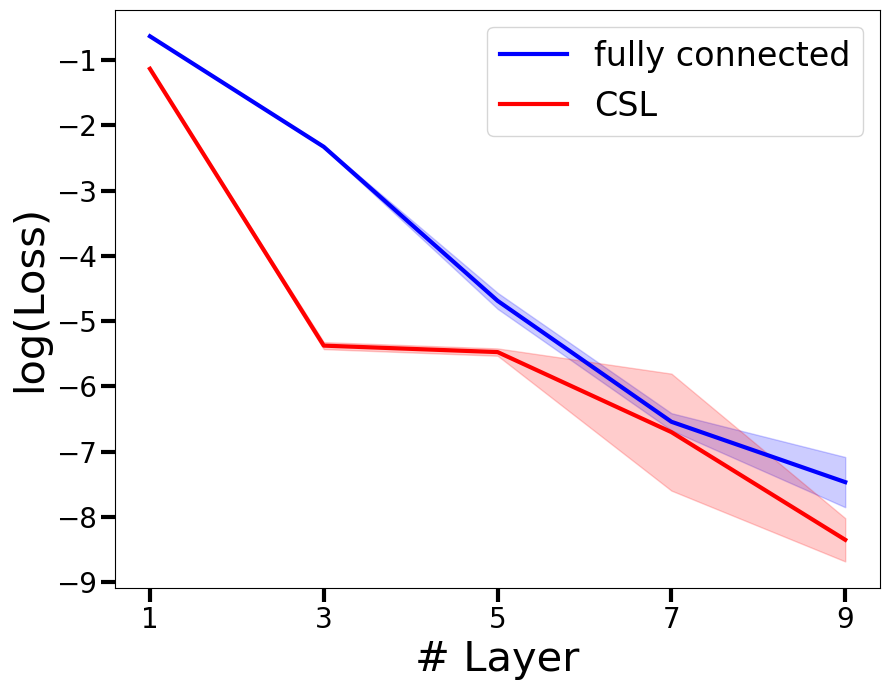

In [327]:
print(loss_means.keys())
#k0 = str({'architecture':'lin', 'obj':'electric', 'data':'fc'})
#k1 = str({'architecture':'lin', 'obj':'electric', 'data':'csl'})
#k2 = str({'architecture':'lin', 'obj':'electric', 'data':'fc', 'PB':'zero'})
#k3 = str({'architecture':'lin', 'obj':'electric', 'data':'csl', 'PB':'zero'})

#k0 = str({'architecture':'stack', 'obj':'resist', 'data':'fc', 'PB':'all', 'ff':'yes'})
#k1 = str({'architecture':'stack', 'obj':'resist', 'data':'csl', 'PB':'all', 'ff':'yes'})

fig, ax = plt.subplots(1, 1,figsize = (9, 7))

plt.plot(n_layers, loss_means[k0], color='blue', lw = 3, label='fully connected')
ax.fill_between(n_layers, loss_means[k0]-loss_stds[k0], loss_means[k0]+loss_stds[k0], color = 'blue', alpha = 0.2)

plt.plot(n_layers, loss_means[k1], color='red', lw = 3, label='CSL')
ax.fill_between(n_layers, loss_means[k1]-loss_stds[k1], loss_means[k1]+loss_stds[k1], color = 'red', alpha = 0.2)

#plt.plot(n_layers, loss_means[k2], color='green', lw = 3, label='FC (const B)')
#ax.fill_between(n_layers, loss_means[k2]-loss_stds[k2], loss_means[k2]+loss_stds[k2], color = 'green', alpha = 0.2)

#plt.plot(n_layers, loss_means[k3], color='orange', lw = 3, label='CSL (const B)')
#ax.fill_between(n_layers, loss_means[k3]-loss_stds[k3], loss_means[k3]+loss_stds[k3], color = 'orange', alpha = 0.2)


ax.set_xlabel('# Layer',fontsize=30)
ax.set_ylabel('log(Loss)',fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20, width = 3, length = 10)
ax.tick_params(axis='both', which='minor', labelsize=20, width = 3, length = 5)
ax.legend(fontsize=24)

plt.xticks([1,3,5,7,9])
plt.tight_layout()
plt.savefig(fig_dir + '/{}_layer.pdf'.format(settings['obj']), dpi=600)